<a href="https://colab.research.google.com/github/JonLiki/CS412-Labs/blob/main/Lab2_LinearRegression_Manual_vs_Pseudo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
n_points = 40
weeks_data = np.sort(np.random.choice(range(1, 48), n_points, replace=False))
sales_data = np.random.randint(10, 20, n_points)

df = pd.DataFrame({
    "Weeks": weeks_data,
    "Sales": sales_data
})

print(df)

    Weeks  Sales
0       1     17
1       2     15
2       4     15
3       5     11
4       6     14
5       7     16
6       8     14
7       9     10
8      10     12
9      11     16
10     12     18
11     13     14
12     15     14
13     17     18
14     18     18
15     20     14
16     21     12
17     22     15
18     23     11
19     24     10
20     25     19
21     26     15
22     27     17
23     28     15
24     29     14
25     30     16
26     31     19
27     33     17
28     34     17
29     36     14
30     37     13
31     38     15
32     39     17
33     40     16
34     42     17
35     43     16
36     44     10
37     45     10
38     46     16
39     47     10


In [ ]:
X = df["Weeks"].values.astype(float)
Y = df["Sales"].values.astype(float)

print("X:", X)
print("Y:", Y)

X: [ 1.  2.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 15. 17. 18. 20. 21. 22.
 23. 24. 25. 26. 27. 28. 29. 30. 31. 33. 34. 36. 37. 38. 39. 40. 42. 43.
 44. 45. 46. 47.]
Y: [17. 15. 15. 11. 14. 16. 14. 10. 12. 16. 18. 14. 14. 18. 18. 14. 12. 15.
 11. 10. 19. 15. 17. 15. 14. 16. 19. 17. 17. 14. 13. 15. 17. 16. 17. 16.
 10. 10. 16. 10.]


In [ ]:
mean_x = np.mean(X)
mean_y = np.mean(Y)
n = len(X)

numer = 0
denom = 0

for i in range(n):
    numer += (X[i] - mean_x) * (Y[i] - mean_y)
    denom += (X[i] - mean_x) ** 2

m1 = numer / denom
c1 = mean_y - (m1 * mean_x)

Y_pred_1 = (m1 * X) + c1
sse1 = np.sum((Y - Y_pred_1) ** 2)
sst1 = np.sum((Y - mean_y) ** 2)
r2_1 = 1 - (sse1 / sst1)

print("Method 1 - Manual Formula")
print(f"Slope (m1): {m1}")
print(f"Intercept (c1): {c1}")
print(f"SSE: {sse1}")
print(f"R^2: {r2_1}")

Method 1 - Manual Formula
Slope (m1): -0.0056215528213831205
Intercept (c1): 14.811041578277472
SSE: 270.5366461603734
R^2: 0.0008802653111498193


In [ ]:
X_mat = np.column_stack([np.ones(n), X])
W = np.linalg.pinv(X_mat) @ Y

c2, m2 = W
Y_pred_2 = X_mat @ W
sse2 = np.sum((Y - Y_pred_2) ** 2)
sst2 = np.sum((Y - np.mean(Y)) ** 2)
r2_2 = 1 - (sse2 / sst2)

print("Method 2 - Matrix / Pseudo-inverse")
print(f"Slope (m2): {m2}")
print(f"Intercept (c2): {c2}")
print(f"SSE: {sse2}")
print(f"R^2: {r2_2}")

Method 2 - Matrix / Pseudo-inverse
Slope (m2): -0.005621552821383085
Intercept (c2): 14.811041578277472
SSE: 270.5366461603734
R^2: 0.0008802653111498193


In [ ]:
print("Comparison")
print(f"Slope difference      : {abs(m1 - m2)}")
print(f"Intercept difference  : {abs(c1 - c2)}")
print(f"SSE difference        : {abs(sse1 - sse2)}")
print(f"R^2 difference        : {abs(r2_1 - r2_2)}")

same_result = (
    np.isclose(m1, m2) and
    np.isclose(c1, c2) and
    np.isclose(sse1, sse2) and
    np.isclose(r2_1, r2_2)
)

print(f"Do both methods give the same result? {same_result}")

Comparison
Slope difference      : 3.5561831257524545e-17
Intercept difference  : 0.0
SSE difference        : 0.0
R^2 difference        : 0.0
Do both methods give the same result? True


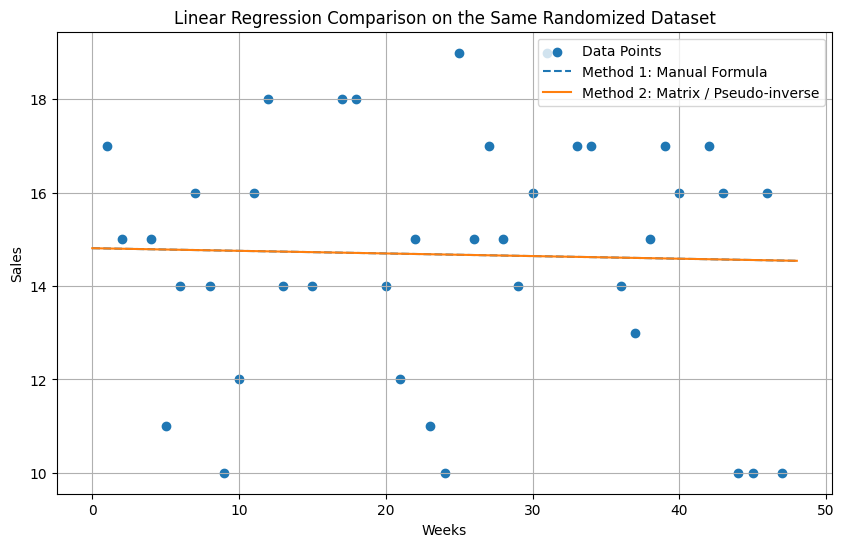

In [ ]:
x_line = np.linspace(np.min(X) - 1, np.max(X) + 1, 100)
y_line_1 = (m1 * x_line) + c1
y_line_2 = (m2 * x_line) + c2

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label="Data Points")
plt.plot(x_line, y_line_1, linestyle="--", label="Method 1: Manual Formula")
plt.plot(x_line, y_line_2, label="Method 2: Matrix / Pseudo-inverse")
plt.xlabel("Weeks")
plt.ylabel("Sales")
plt.title("Linear Regression Comparison on the Same Randomized Dataset")
plt.grid(True)
plt.legend(loc="best")
plt.show()

In [ ]:
num_points = 50

x1 = np.random.uniform(0, 4, num_points)
y1 = np.random.uniform(0, 4, num_points)
x2 = np.random.uniform(6, 10, num_points)
y2 = np.random.uniform(6, 10, num_points)


In [ ]:
pts1 = np.column_stack((x1, y1))
pts2 = np.column_stack((x2, y2))
points = np.vstack((pts1, pts2))

labels1 = np.ones(num_points)
labels2 = -np.ones(num_points)
labels = np.hstack((labels1, labels2))

In [ ]:
X = np.column_stack((np.ones(len(points)), points[:, 0], points[:, 1]))

In [ ]:
w = np.linalg.pinv(X) @ labels

In [ ]:
xx = np.linspace(np.min(points[:, 0]) - 1, np.max(points[:, 0]) + 1, 100)
yy = -(w[0] + w[1] * xx) / w[2]

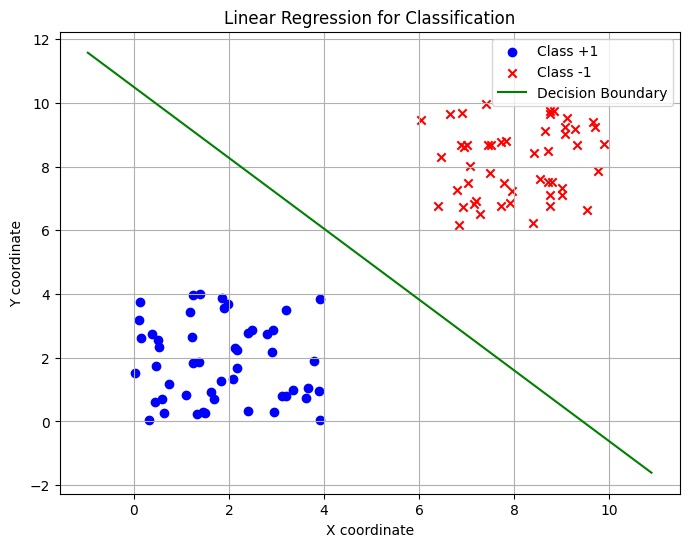

In [ ]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, color='blue', label='Class +1')
plt.scatter(x2, y2, color='red', marker='x', label='Class -1')
plt.plot(xx, yy, color='green', label='Decision Boundary')

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Linear Regression for Classification")
plt.legend()
plt.grid(True)
plt.show()